# Visualize simulated trajectories

Browses the trajectory library produced by `utils/trajectory_generator.py` (saved under
`simulated_trajectories/`), using `utils/trajectory_visualizer.py`'s `TrajectoryVisualizer`
class. This is meant as a quick sanity-check tool: confirm each motif looks like what it's
supposed to, and that the randomized parameters actually span a reasonable range, before using
the dataset to train the ANN estimators in `elaborate_plan.md` Phase 2.

If `simulated_trajectories/manifest.csv` doesn't exist yet, run
`python3 utils/trajectory_generator.py` first (see that file's docstring for options).

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('.').resolve()))
from utils.trajectory_visualizer import TrajectoryVisualizer

/home/cherry/Documents/ai_kalman_on_crazyflie/.venv/lib/python3.12/site-packages/do_mpc/sysid/__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
/home/cherry/Documents/ai_kalman_on_crazyflie/.venv/lib/python3.12/site-packages/do_mpc/opcua/__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')


## Load the manifest

`manifest.csv` records every generated trajectory's filename and parameters (embedded as a JSON
string per row, produced by `trajectory_generator.py`'s motif functions). We parse out the
`motif` field here for easy filtering/grouping below.

In [2]:
SIMULATED_TRAJECTORIES_DIR = Path('simulated_trajectories')
manifest_path = SIMULATED_TRAJECTORIES_DIR / 'manifest.csv'

if not manifest_path.exists():
    print(f'No manifest found at {manifest_path}.')
    print('Run `python3 utils/trajectory_generator.py` first to generate trajectories.')
    manifest = None
else:
    manifest = pd.read_csv(manifest_path)
    manifest['motif'] = manifest['params_json'].apply(lambda s: json.loads(s)['motif'])
    print(f'{len(manifest)} trajectories found in {SIMULATED_TRAJECTORIES_DIR}')
    print(manifest['motif'].value_counts())

manifest

2 trajectories found in simulated_trajectories
motif
sinusoidal    2
Name: count, dtype: int64


,filename,index,seed,params_json,motif
0,sinusoidal_0000.csv.gz,0,0,"{""motif"": ""sinusoidal"", ""z_level_m"": 0.3280969...",sinusoidal
1,sinusoidal_0001.csv.gz,1,1,"{""motif"": ""sinusoidal"", ""z_level_m"": 1.9127040...",sinusoidal


## Gallery: one example x-y trajectory per motif

A quick at-a-glance check that every motif produces a sensible flight path. Motifs with little or
no net translation (e.g. a pure `turn` at zero base speed, or `casting` with zero forward speed)
will understandably show a small/degenerate path here -- that's expected, not a bug.

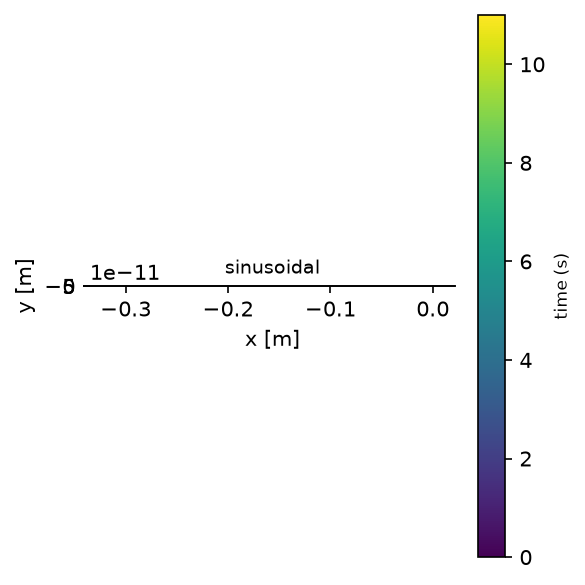

In [3]:
if manifest is not None:
    motifs_present = sorted(manifest['motif'].unique())
    ncols = min(4, len(motifs_present))
    nrows = int(np.ceil(len(motifs_present) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), dpi=150, squeeze=False)
    axes_flat = axes.flatten()

    for i, motif in enumerate(motifs_present):
        example_filename = manifest[manifest['motif'] == motif].iloc[0]['filename']
        viz = TrajectoryVisualizer(SIMULATED_TRAJECTORIES_DIR / example_filename)
        viz.plot_trajectory_xy(ax=axes_flat[i])
        axes_flat[i].set_title(motif, fontsize=9)

    for ax in axes_flat[len(motifs_present):]:
        ax.axis('off')

    fig.tight_layout()
    plt.show()
else:
    print('Skipping gallery -- no trajectories yet.')

## Detailed look at one trajectory

Change `TRAJECTORY_FILE` below to inspect any other file (or filter `manifest` by motif first,
e.g. `manifest[manifest['motif'] == 'accel_decel']`, and pick a filename from there).

file: simulated_trajectories/sinusoidal_0000.csv.gz
rows: 1101  duration: 11.00s
states (12): ['x', 'y', 'z', 'v_x', 'v_y', 'v_z', 'psi', 'w', 'zeta', 'k_x', 'k_y', 'k_psi']
inputs (6): ['u_x', 'u_y', 'u_psi', 'u_z', 'u_w', 'u_zeta']
measurements (13): ['v_x_dot', 'v_y_dot', 'r_x', 'r_y', 'r', 'g', 'beta', 'a_x', 'a_y', 'a', 'gamma', 'w_x', 'w_y']
metadata: {'motif': 'sinusoidal', 'z_level_m': 0.32809698039849944, 'dt': 0.01, 'length_s': 11.0, 'mpc_horizon': 10, 'freq_hz': 0.3366327592946544, 'amplitude_mps': 0.3428080423874833, 'phase_rad': -2.8841484100105235}


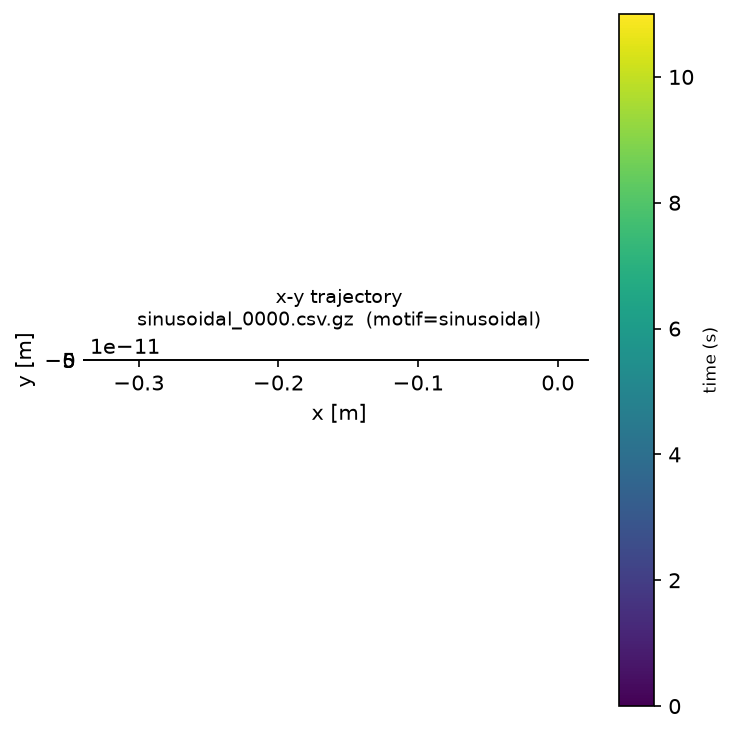

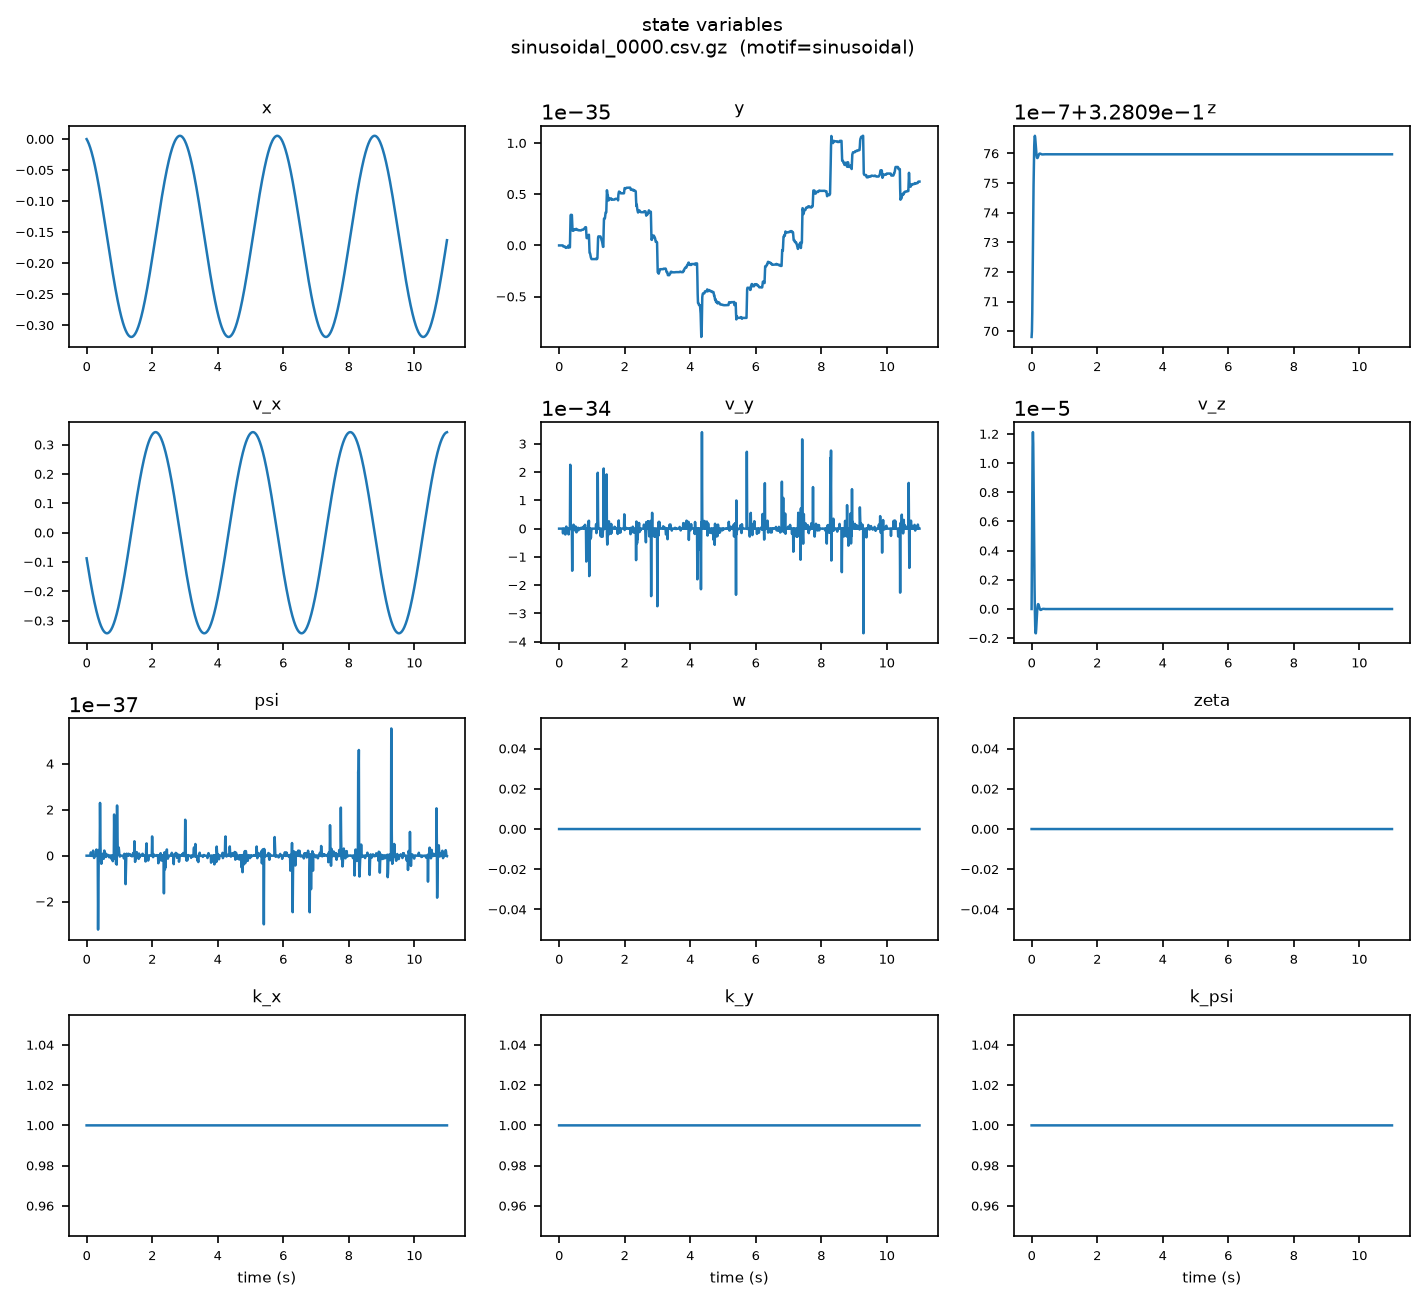

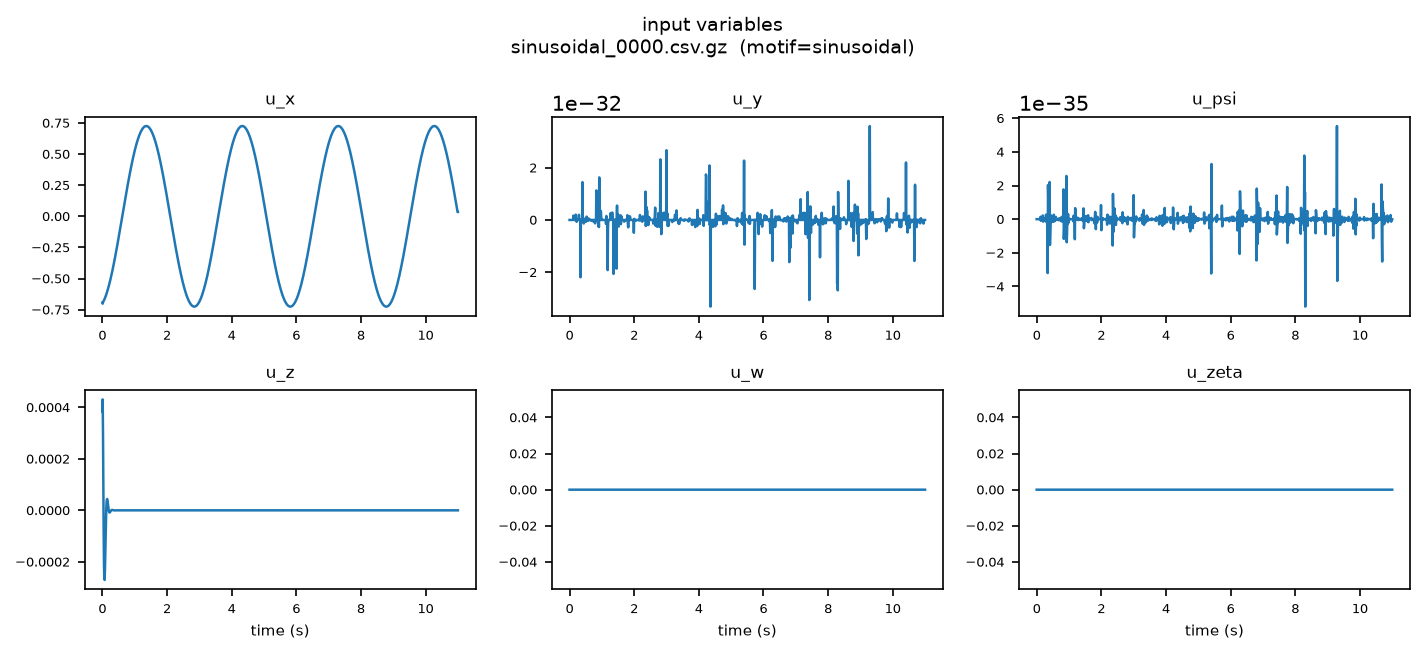

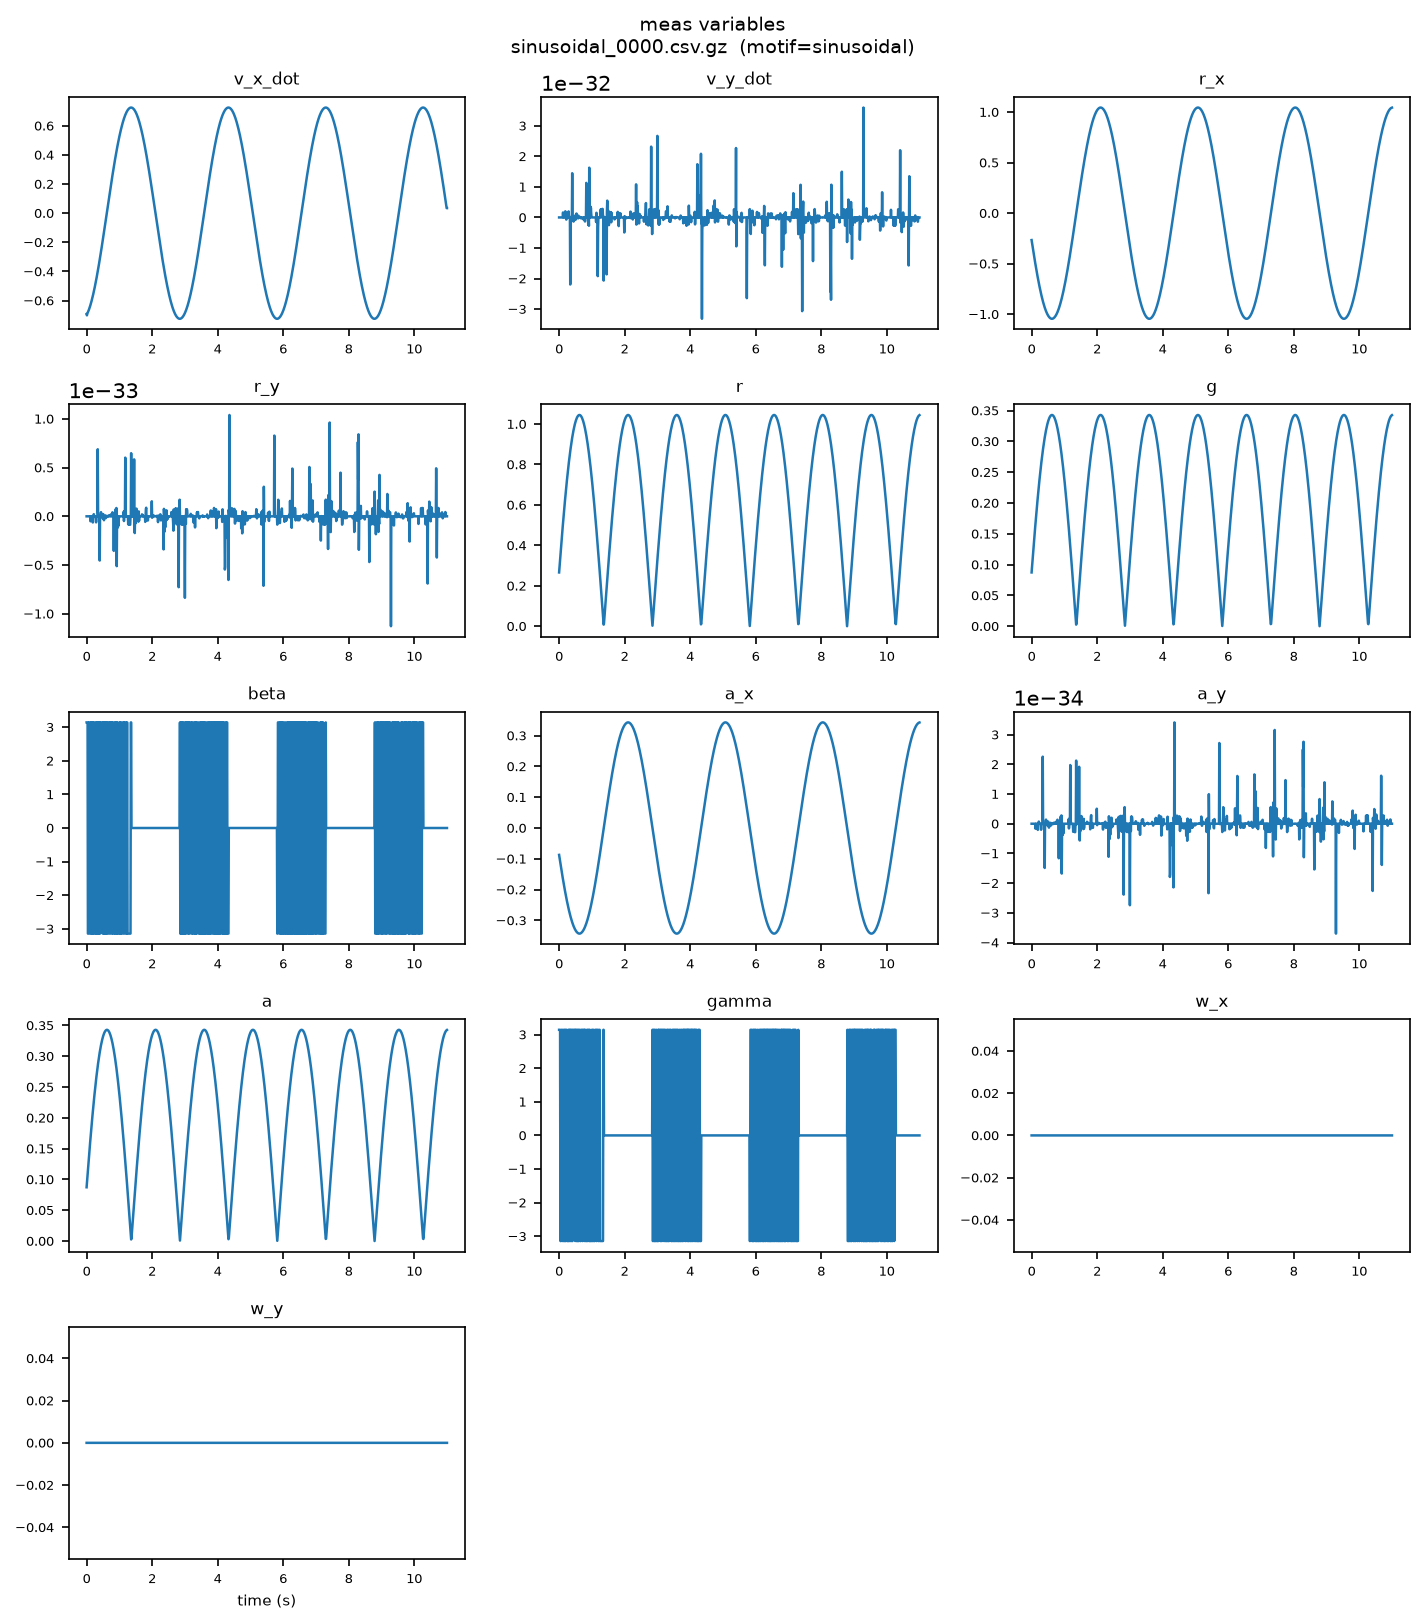

In [4]:
if manifest is not None:
    TRAJECTORY_FILE = SIMULATED_TRAJECTORIES_DIR / manifest.iloc[0]['filename']

    viz = TrajectoryVisualizer(TRAJECTORY_FILE)
    viz.summary()
    viz.plot_all(show=True)

## Parameter diversity within one motif

Overlaying `v_x` from several trajectories of the same motif is a fast way to confirm the
randomized parameters (frequency, amplitude, peak speed, timing, ...) actually span a reasonable
range, rather than all trajectories looking nearly identical.

In [ ]:
if manifest is not None:
    MOTIF_TO_CHECK = 'accel_decel' if 'accel_decel' in manifest['motif'].values else manifest['motif'].iloc[0]
    example_files = manifest[manifest['motif'] == MOTIF_TO_CHECK]['filename'].head(6).tolist()

    fig, ax = plt.subplots(1, 1, figsize=(7, 4), dpi=150)
    for filename in example_files:
        viz = TrajectoryVisualizer(SIMULATED_TRAJECTORIES_DIR / filename)
        if 'state_v_x' in viz.df.columns:
            ax.plot(viz.time, viz.df['state_v_x'], alpha=0.8, linewidth=1.2, label=filename)

    ax.set_xlabel('time (s)')
    ax.set_ylabel('v_x [m/s]')
    ax.set_title(f'v_x diversity across "{MOTIF_TO_CHECK}" trajectories (n={len(example_files)})')
    ax.legend(fontsize=6)
    fig.tight_layout()
    plt.show()
else:
    print('Skipping diversity check -- no trajectories yet.')